# 04_208 · Auditoría común de etiquetas finas y transversales

Este cuaderno **no entrena** ni altera modelos. Evalúa todos los resultados disponibles sobre el mismo `test` 4:1 y deja explícito qué papel cumplen las anotaciones auxiliares.
Al arrancar verifica el bundle de Drive y, si hay conflicto, conserva el artefacto más reciente según la fecha interna del resultado o el mtime; el ganador puede ser Drive o local. La tabla muestra ambas fechas, el criterio y el origen elegido. Qwen plano se carga mediante la selección operativa de validation (época 3), no mediante el alias `best_adapter`.

- En `04_205`, las etiquetas finas y los flags se usan como **objetivos auxiliares predichos** durante el fine-tuning de Qwen.
- En `04_206`, sus logits predichos se reutilizan como características latentes; nunca se inyectan etiquetas gold en inferencia.
- En los modelos clásicos y Transformers restantes, el entrenamiento es `coarse-only`; las etiquetas finas y transversales se usan aquí para auditar subgrupos, errores y priorización de revisión humana.

Usar las etiquetas auxiliares gold como predictores produciría fuga de información, porque no estarán disponibles para chunks nuevos en producción.

In [1]:
from pathlib import Path
import hashlib, importlib, json, subprocess, sys
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'cuadernos':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display, Markdown, Image

# Sincronización Drive ↔ workspace. En un conflicto gana el artefacto más
# reciente, determinado por completed_at/generated_at o por mtime como respaldo.
DRIVE_BUNDLE = Path(r'G:\My Drive\PLN_colab_04_artifacts')
RECOVERY_SCRIPT = ROOT / 'scripts_auxiliares' / 'recuperar_resultados_colab_04_20x.ps1'
SYNC_TARGETS = {
    '04_205 Qwen plano operativo': Path('resultados/metricas/qwen3_06b_lora_acoso_amenaza_4/evaluacion_test_modelo_seleccionado.json'),
    '04_206 Qwen jerárquico': Path('resultados/metricas/qwen_jerarquico_4/resultado.json'),
    '04_202 Transformer plano': Path('resultados/metricas/transformer_plano_4/resultado.json'),
    '04_203 Transformer cascada': Path('resultados/metricas/experimentos_jerarquicos_4/cascada_binaria_multietiqueta_4_seguros_ampliados/resultado.json'),
    '04_204 Transformer jerárquico': Path('resultados/metricas/experimentos_jerarquicos_4/transformer_jerarquico_multitarea_4/resultado.json'),
}

def _sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''): digest.update(block)
    return digest.hexdigest()

TIMESTAMP_FIELDS = ('completed_at', 'generated_at', 'created_at', 'finished_at', 'updated_at')

def _artifact_timestamp(path):
    path = Path(path)
    if path.suffix.lower() == '.json':
        try:
            payload = json.loads(path.read_text(encoding='utf-8-sig'))
            for field in TIMESTAMP_FIELDS:
                if payload.get(field):
                    stamp = pd.Timestamp(payload[field])
                    # Una fecha sin zona es ambigua entre Colab/GMT y Lima.
                    # Sólo se usa si declara Z u offset; siempre se convierte a UTC.
                    if stamp.tzinfo is not None:
                        return stamp.tz_convert('UTC').timestamp(), f'{field}→UTC'
        except Exception:
            pass
    return path.stat().st_mtime, 'mtime_utc'

def _stamp_text(value):
    return pd.Timestamp(value, unit='s', tz='UTC').isoformat() if value is not None else None

def _sync_state(relative):
    local, remote = ROOT / relative, DRIVE_BUNDLE / relative
    if local.is_file() and remote.is_file():
        if _sha256(local) == _sha256(remote):
            stamp, basis = _artifact_timestamp(local)
            return {'estado': 'idéntico', 'elegido': 'ambos', 'fecha_local': stamp, 'fecha_drive': stamp, 'criterio': basis}
        local_stamp, local_basis = _artifact_timestamp(local)
        drive_stamp, drive_basis = _artifact_timestamp(remote)
        if drive_stamp > local_stamp:
            chosen = 'Drive'
        elif local_stamp > drive_stamp:
            chosen = 'local'
        else:
            chosen = 'empate no resoluble'
        return {'estado': 'conflicto', 'elegido': chosen, 'fecha_local': local_stamp, 'fecha_drive': drive_stamp, 'criterio': f'local:{local_basis}; Drive:{drive_basis}'}
    if local.is_file():
        stamp, basis = _artifact_timestamp(local)
        return {'estado': 'solo local', 'elegido': 'local', 'fecha_local': stamp, 'fecha_drive': None, 'criterio': basis}
    if remote.is_file():
        stamp, basis = _artifact_timestamp(remote)
        return {'estado': 'solo Drive', 'elegido': 'Drive', 'fecha_local': None, 'fecha_drive': stamp, 'criterio': basis}
    return {'estado': 'ausente', 'elegido': 'ninguno', 'fecha_local': None, 'fecha_drive': None, 'criterio': None}

states_before = {name: _sync_state(path) for name, path in SYNC_TARGETS.items()}
ties = [name for name, state in states_before.items() if state['elegido'] == 'empate no resoluble']
if ties:
    raise RuntimeError('Conflictos con la misma fecha y hashes distintos: ' + ', '.join(ties))
drive_winners = [name for name, state in states_before.items() if state['elegido'] == 'Drive']
if drive_winners:
    if sys.platform != 'win32' or not RECOVERY_SCRIPT.is_file():
        raise RuntimeError('Drive tiene artefactos más recientes, pero no está disponible el recuperador local.')
    common = ['powershell', '-NoProfile', '-ExecutionPolicy', 'Bypass', '-File', str(RECOVERY_SCRIPT), '-Workspace', str(ROOT), '-DriveBundle', str(DRIVE_BUNDLE), '-PreferNewest']
    modes = []
    if any(name.startswith(('04_202', '04_203', '04_204')) for name in drive_winners): modes.append('-ComparisonOnly')
    if any(name.startswith('04_205') for name in drive_winners): modes.append('-Qwen04_205Only')
    if any(name.startswith('04_206') for name in drive_winners): modes.append('-Qwen04_206Only')
    for mode in modes:
        recovery = subprocess.run([*common, mode], text=True, capture_output=True)
        if recovery.returncode != 0: raise RuntimeError(f'Falló la sincronización {mode}:\n' + (recovery.stderr or recovery.stdout))
        print(recovery.stdout.strip())
elif not DRIVE_BUNDLE.is_dir():
    print(f'Drive no está disponible en {DRIVE_BUNDLE}; se usarán resultados locales.')

deployment_required = [ROOT / 'modelos/transformer_plano_4/e5_small/best_checkpoint.pt', ROOT / 'modelos/transformer_plano_4/e5_small/tokenizer/tokenizer.json']
if any(not path.is_file() for path in deployment_required) and sys.platform == 'win32' and DRIVE_BUNDLE.is_dir():
    recovery = subprocess.run(['powershell', '-NoProfile', '-ExecutionPolicy', 'Bypass', '-File', str(RECOVERY_SCRIPT), '-Workspace', str(ROOT), '-DriveBundle', str(DRIVE_BUNDLE), '-DeploymentOnly'], text=True, capture_output=True)
    if recovery.returncode != 0: raise RuntimeError('Falló la recuperación para el registro de 05:\n' + (recovery.stderr or recovery.stdout))
    print(recovery.stdout.strip())

states_after = {name: _sync_state(path) for name, path in SYNC_TARGETS.items()}
def _resolution_text(before, after):
    if before['estado'] == 'conflicto':
        return f"resuelto: se conserva {before['elegido']} (más reciente)"
    if before['estado'] == 'solo Drive' and after['estado'] == 'idéntico':
        return 'copiado desde Drive'
    return after['estado']

sync_status = pd.DataFrame([
    {
        'cuaderno': name,
        'estado_antes': states_before[name]['estado'],
        'fecha_local': _stamp_text(states_before[name]['fecha_local']),
        'fecha_drive': _stamp_text(states_before[name]['fecha_drive']),
        'origen_elegido': states_before[name]['elegido'],
        'criterio': states_before[name]['criterio'],
        'estado_después': _resolution_text(states_before[name], states_after[name]),
    }
    for name, path in SYNC_TARGETS.items()
])
display(Markdown('### Verificación Drive → workspace'))
display(sync_status)

from scripts_auxiliares import entrenar_qwen_acoso_amenaza as q4
from scripts_auxiliares import analizar_auxiliares_modelos_4 as audit4
from scripts_auxiliares import registro_modelos_produccion_4 as deploy4
# Evita reutilizar versiones antiguas conservadas por el kernel.
importlib.invalidate_caches()
q4 = importlib.reload(q4)
audit4 = importlib.reload(audit4)
deploy4 = importlib.reload(deploy4)
operational_qwen = q4.load_operational_evaluation(load_scores=False, require_test=True)
display({'qwen_checkpoint_operativo': operational_qwen['selected_epoch'], 'seleccion': str(q4.OPERATIONAL_SELECTION_PATH.relative_to(ROOT)), 'test_usado_para_seleccion': False})

### Verificación Drive → workspace

,cuaderno,estado_antes,fecha_local,fecha_drive,origen_elegido,criterio,estado_después
0,04_205 Qwen plano operativo,idéntico,2026-07-29T15:45:16+00:00,2026-07-29T15:45:16+00:00,ambos,completed_at→UTC,idéntico
1,04_206 Qwen jerárquico,conflicto,2026-07-29T18:05:12+00:00,2026-07-29T17:24:58+00:00,local,local:completed_at→UTC; Drive:completed_at→UTC,resuelto: se conserva local (más reciente)
2,04_202 Transformer plano,idéntico,2026-07-28T13:35:28+00:00,2026-07-28T13:35:28+00:00,ambos,completed_at→UTC,idéntico
3,04_203 Transformer cascada,idéntico,2026-07-28T10:04:18+00:00,2026-07-28T10:04:18+00:00,ambos,created_at→UTC,idéntico
4,04_204 Transformer jerárquico,idéntico,2026-07-28T15:10:32+00:00,2026-07-28T15:10:32+00:00,ambos,created_at→UTC,idéntico


{'qwen_checkpoint_operativo': 3,
 'seleccion': 'resultados\\metricas\\qwen3_06b_lora_acoso_amenaza_4\\seleccion_operativa_validacion.json',
 'test_usado_para_seleccion': False}

## 1. Inventario antes de ejecutar

La celda siguiente permite saber qué experimentos ya terminaron. Los resultados ausentes quedan registrados; no se inventan ni se sustituyen por ejecuciones parciales.

In [2]:
available, missing = audit4.collect_models()
deployment_registry = deploy4.load_registry(verify_hashes=True)
display({
    'modelos_disponibles': [m['label'] for m in available],
    'regimen_de_supervision': {m['label']: m['regime'] for m in available},
    'resultados_pendientes': missing,
    'modelos_publicados_para_05': {slot: value['label'] for slot, value in deployment_registry['models'].items()},
})

{'modelos_disponibles': ['Qwen 04_205 plano · época operativa 3',
  'Paraphrase Multilingual MiniLM-L12 plano',
  'Multilingual E5-small (linaje MiniLM) plano',
  'Cascada binaria → cuatro daños, SEGURO ampliado',
  'Transformer jerárquico multitarea → cuatro daños',
  'Regresión logística calibrada · Cascada binaria → multietiqueta',
  'Regresión logística calibrada · Plano',
  'Regresión logística calibrada · Jerárquico clásico con TF-IDF compartido',
  'SVM lineal calibrado palabra+carácter · Cascada binaria → multietiqueta',
  'SVM lineal calibrado palabra+carácter · Plano',
  'SVM lineal calibrado palabra+carácter · Jerárquico clásico con TF-IDF compartido',
  'Qwen congelado + cascada calibrada',
  'Qwen congelado + cabeza jerárquica multitarea'],
 'regimen_de_supervision': {'Qwen 04_205 plano · época operativa 3': 'coarse + fine/flag auxiliary multitask',
  'Paraphrase Multilingual MiniLM-L12 plano': 'coarse-only',
  'Multilingual E5-small (linaje MiniLM) plano': 'coarse-only',


## 2. Ejecutar la auditoría reproducible

Para cada etiqueta fina se calcula recall de su categoría gruesa (o especificidad para variantes de `SEGURO`). Para cada flag transversal se mide qué proporción queda capturada al revisar el 10% y 20% de chunks más cercanos a los umbrales de decisión. Esta es una auditoría descriptiva común, no una prueba causal de que la supervisión auxiliar sea responsable de una diferencia.

In [3]:
result = audit4.run_analysis(review_fractions=(0.10, 0.20))
display(result)

{'completed_at': '2026-07-29T14:26:39-05:00',
 'dataset_sha256': 'df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc51c881be944670ef20f',
 'test_rows': 5290,
 'models_analyzed': [{'key': 'qwen4_flat',
   'label': 'Qwen 04_205 plano · época operativa 3',
   'regime': 'coarse + fine/flag auxiliary multitask',
   'checkpoint_provenance': {'selected_epoch': 3,
    'selected_adapter': 'modelos/qwen3_06b_lora_acoso_amenaza_4/epoch_adapters/epoch_03',
    'selection_artifact': {'path': 'resultados/metricas/qwen3_06b_lora_acoso_amenaza_4/seleccion_operativa_validacion.json',
     'sha256': '3f677e6f2f71f413bbc4dd3b3f4e14e4b36ba07a5e2c8379ede2bc3c45914e29',
     'bytes': 6088},
    'test_used_for_selection': False}},
  {'key': 'transformer_flat__paraphrase_minilm',
   'label': 'Paraphrase Multilingual MiniLM-L12 plano',
   'regime': 'coarse-only',
   'checkpoint_provenance': None},
  {'key': 'transformer_flat__e5_small',
   'label': 'Multilingual E5-small (linaje MiniLM) plano',
   'regime': 'coarse

In [4]:
import pandas as pd

fine = pd.read_csv(audit4.OUTPUT_DIR / 'desempeno_por_etiqueta_fina.csv')
flags = pd.read_csv(audit4.OUTPUT_DIR / 'captura_flags_por_incertidumbre.csv')
display(fine.sort_values(['fine_label', 'value'], ascending=[True, False]))
display(flags.sort_values(['review_fraction', 'flag', 'flag_capture'], ascending=[True, True, False]))

,model_key,modelo,supervision_regime,fine_label,coarse_target,n,metric,value
9,qwen4_flat,Qwen 04_205 plano · época operativa 3,coarse + fine/flag auxiliary multitask,acoso_personal,ACOSO_AMENAZA,326,target_recall,0.647239
37,transformer_flat__e5_small,Multilingual E5-small (linaje MiniLM) plano,coarse-only,acoso_personal,ACOSO_AMENAZA,326,target_recall,0.619632
177,qwen_frozen_joint,Qwen congelado + cabeza jerárquica multitarea,frozen Qwen coarse + auxiliary logits,acoso_personal,ACOSO_AMENAZA,326,target_recall,0.601227
163,qwen_frozen_cascade,Qwen congelado + cascada calibrada,frozen Qwen coarse + auxiliary logits,acoso_personal,ACOSO_AMENAZA,326,target_recall,0.536810
93,classic__logistic__flat,Regresión logística calibrada · Plano,coarse-only,acoso_personal,ACOSO_AMENAZA,326,target_recall,0.521472
...,...,...,...,...,...,...,...,...
83,classic__logistic__cascade,Regresión logística calibrada · Cascada binari...,coarse-only,sexual_no_consensual,CONTENIDO_SEXUAL,9,target_recall,0.222222
111,classic__logistic__shared_hierarchy,Regresión logística calibrada · Jerárquico clá...,coarse-only,sexual_no_consensual,CONTENIDO_SEXUAL,9,target_recall,0.222222
153,classic__svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,coarse-only,sexual_no_consensual,CONTENIDO_SEXUAL,9,target_recall,0.222222
181,qwen_frozen_joint,Qwen congelado + cabeza jerárquica multitarea,frozen Qwen coarse + auxiliary logits,sexual_no_consensual,CONTENIDO_SEXUAL,9,target_recall,0.222222


,model_key,modelo,supervision_regime,review_fraction,flag,flag_n,flag_capture,missed_damage_n,missed_damage_capture
44,classic__logistic__shared_hierarchy,Regresión logística calibrada · Jerárquico clá...,coarse-only,0.1,contexto_necesario,95,0.357895,575,0.149565
38,classic__logistic__flat,Regresión logística calibrada · Plano,coarse-only,0.1,contexto_necesario,95,0.315789,395,0.129114
26,transformer_jerarquico_multitarea_4,Transformer jerárquico multitarea → cuatro daños,coarse-only; expanded binary supervision,0.1,contexto_necesario,95,0.305263,629,0.273450
74,qwen_frozen_joint,Qwen congelado + cabeza jerárquica multitarea,frozen Qwen coarse + auxiliary logits,0.1,contexto_necesario,95,0.305263,375,0.114667
32,classic__logistic__cascade,Regresión logística calibrada · Cascada binari...,coarse-only,0.1,contexto_necesario,95,0.294737,431,0.116009
...,...,...,...,...,...,...,...,...,...
51,classic__svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,coarse-only,0.2,ironia_ambigua,31,0.387097,481,0.282744
15,transformer_flat__e5_small,Multilingual E5-small (linaje MiniLM) plano,coarse-only,0.2,ironia_ambigua,31,0.322581,270,0.251852
57,classic__svm__flat,SVM lineal calibrado palabra+carácter · Plano,coarse-only,0.2,ironia_ambigua,31,0.322581,428,0.338785
27,transformer_jerarquico_multitarea_4,Transformer jerárquico multitarea → cuatro daños,coarse-only; expanded binary supervision,0.2,ironia_ambigua,31,0.258065,629,0.538951


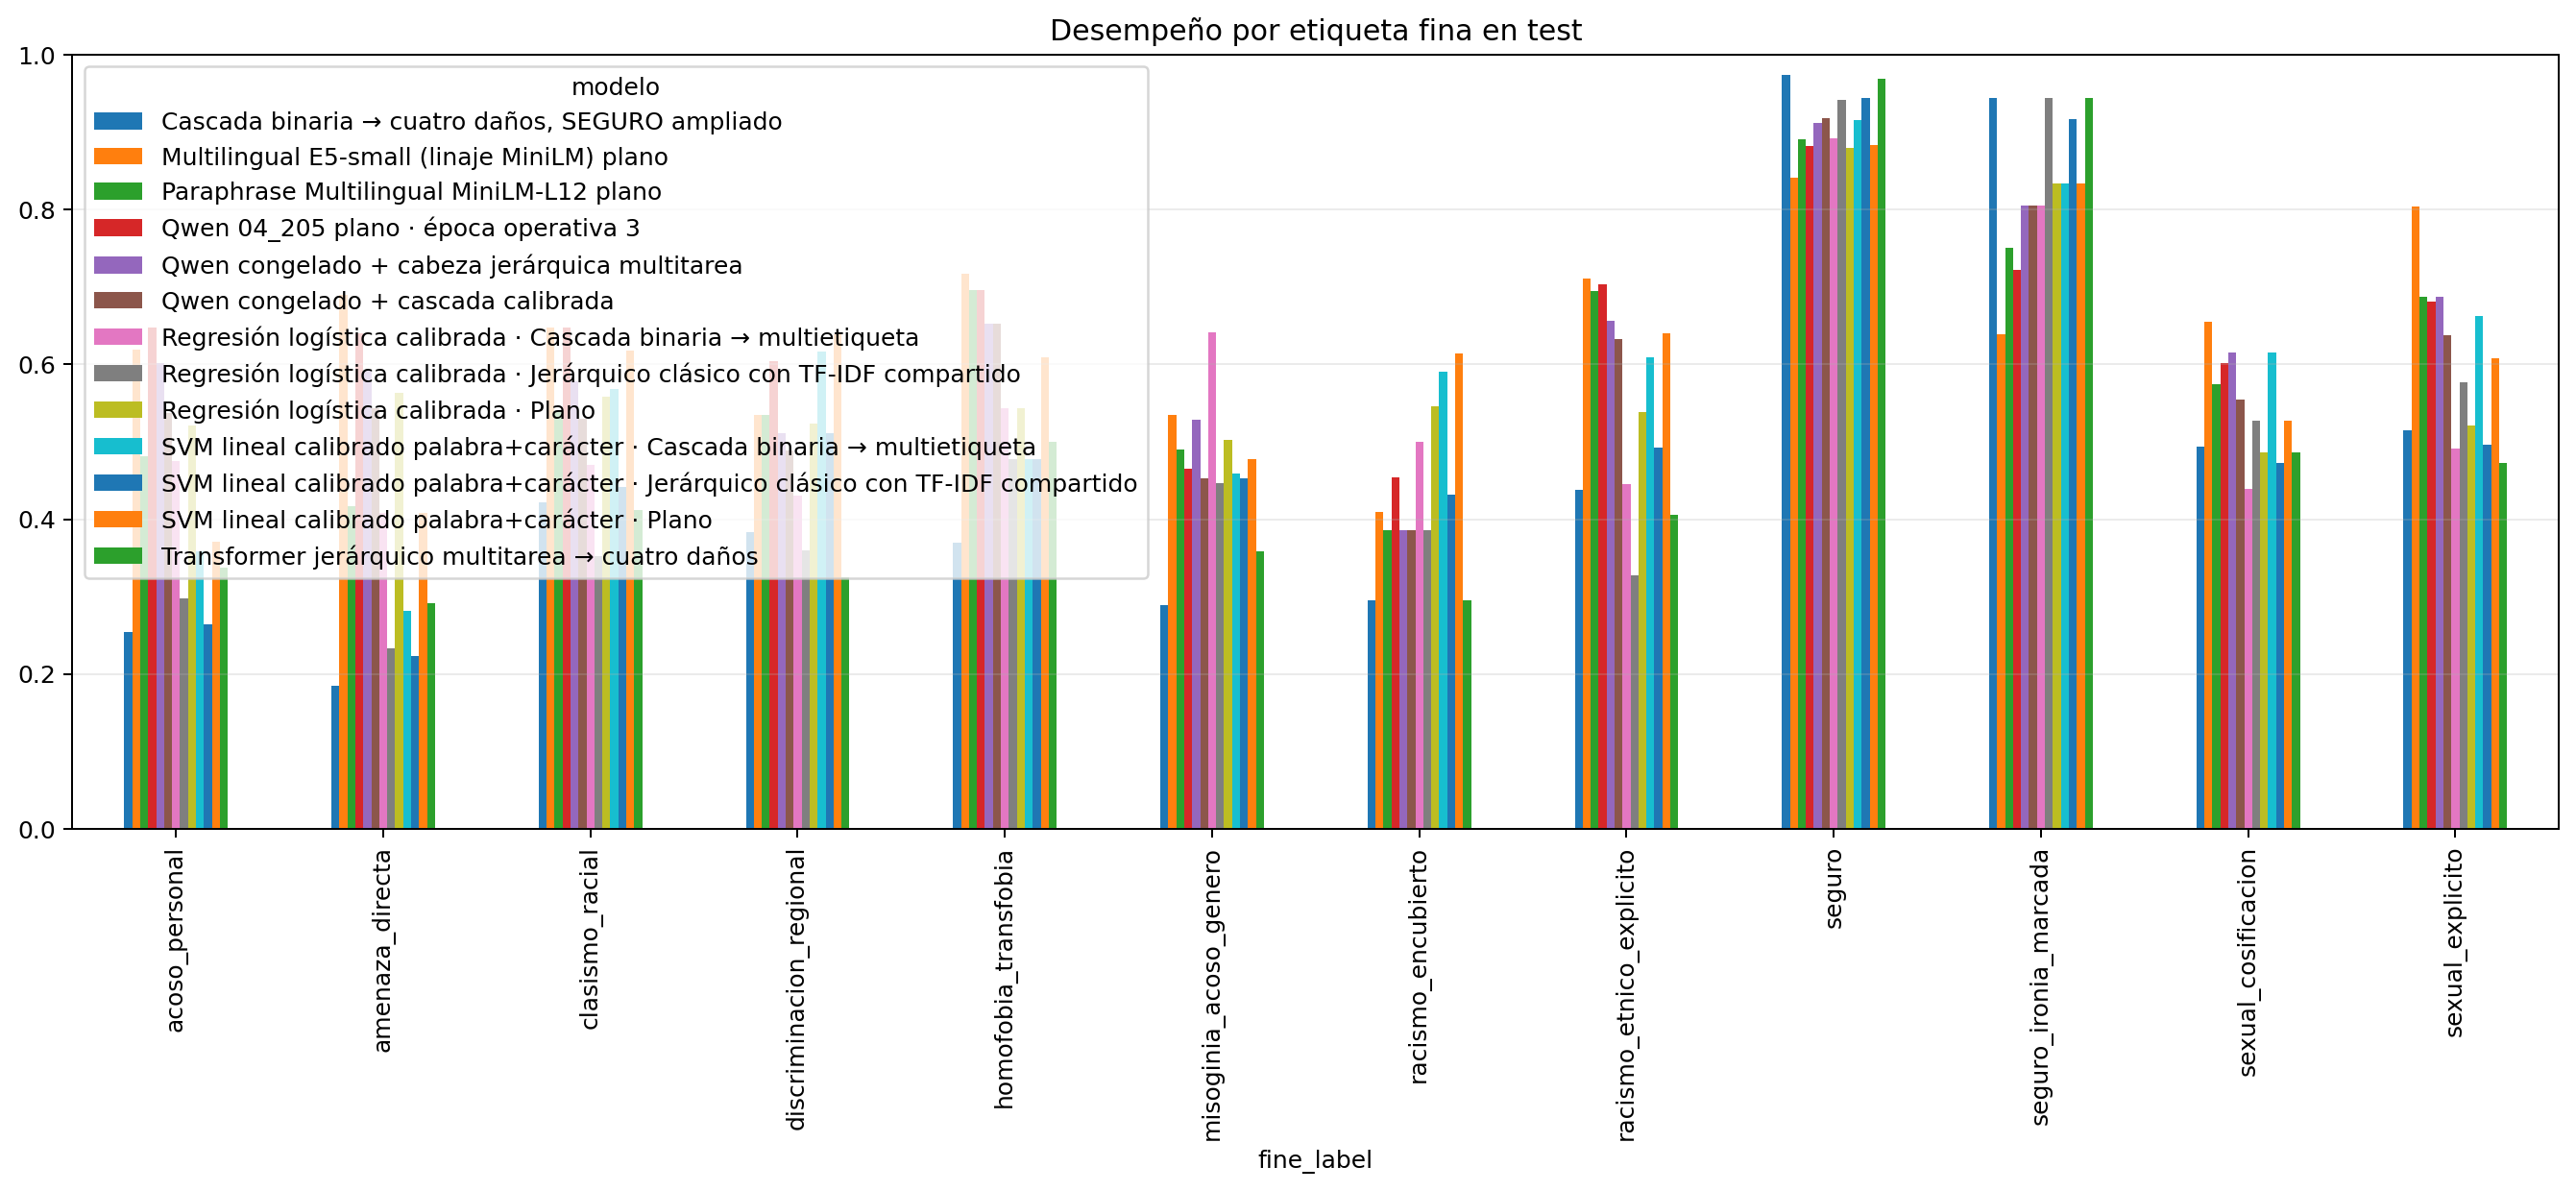

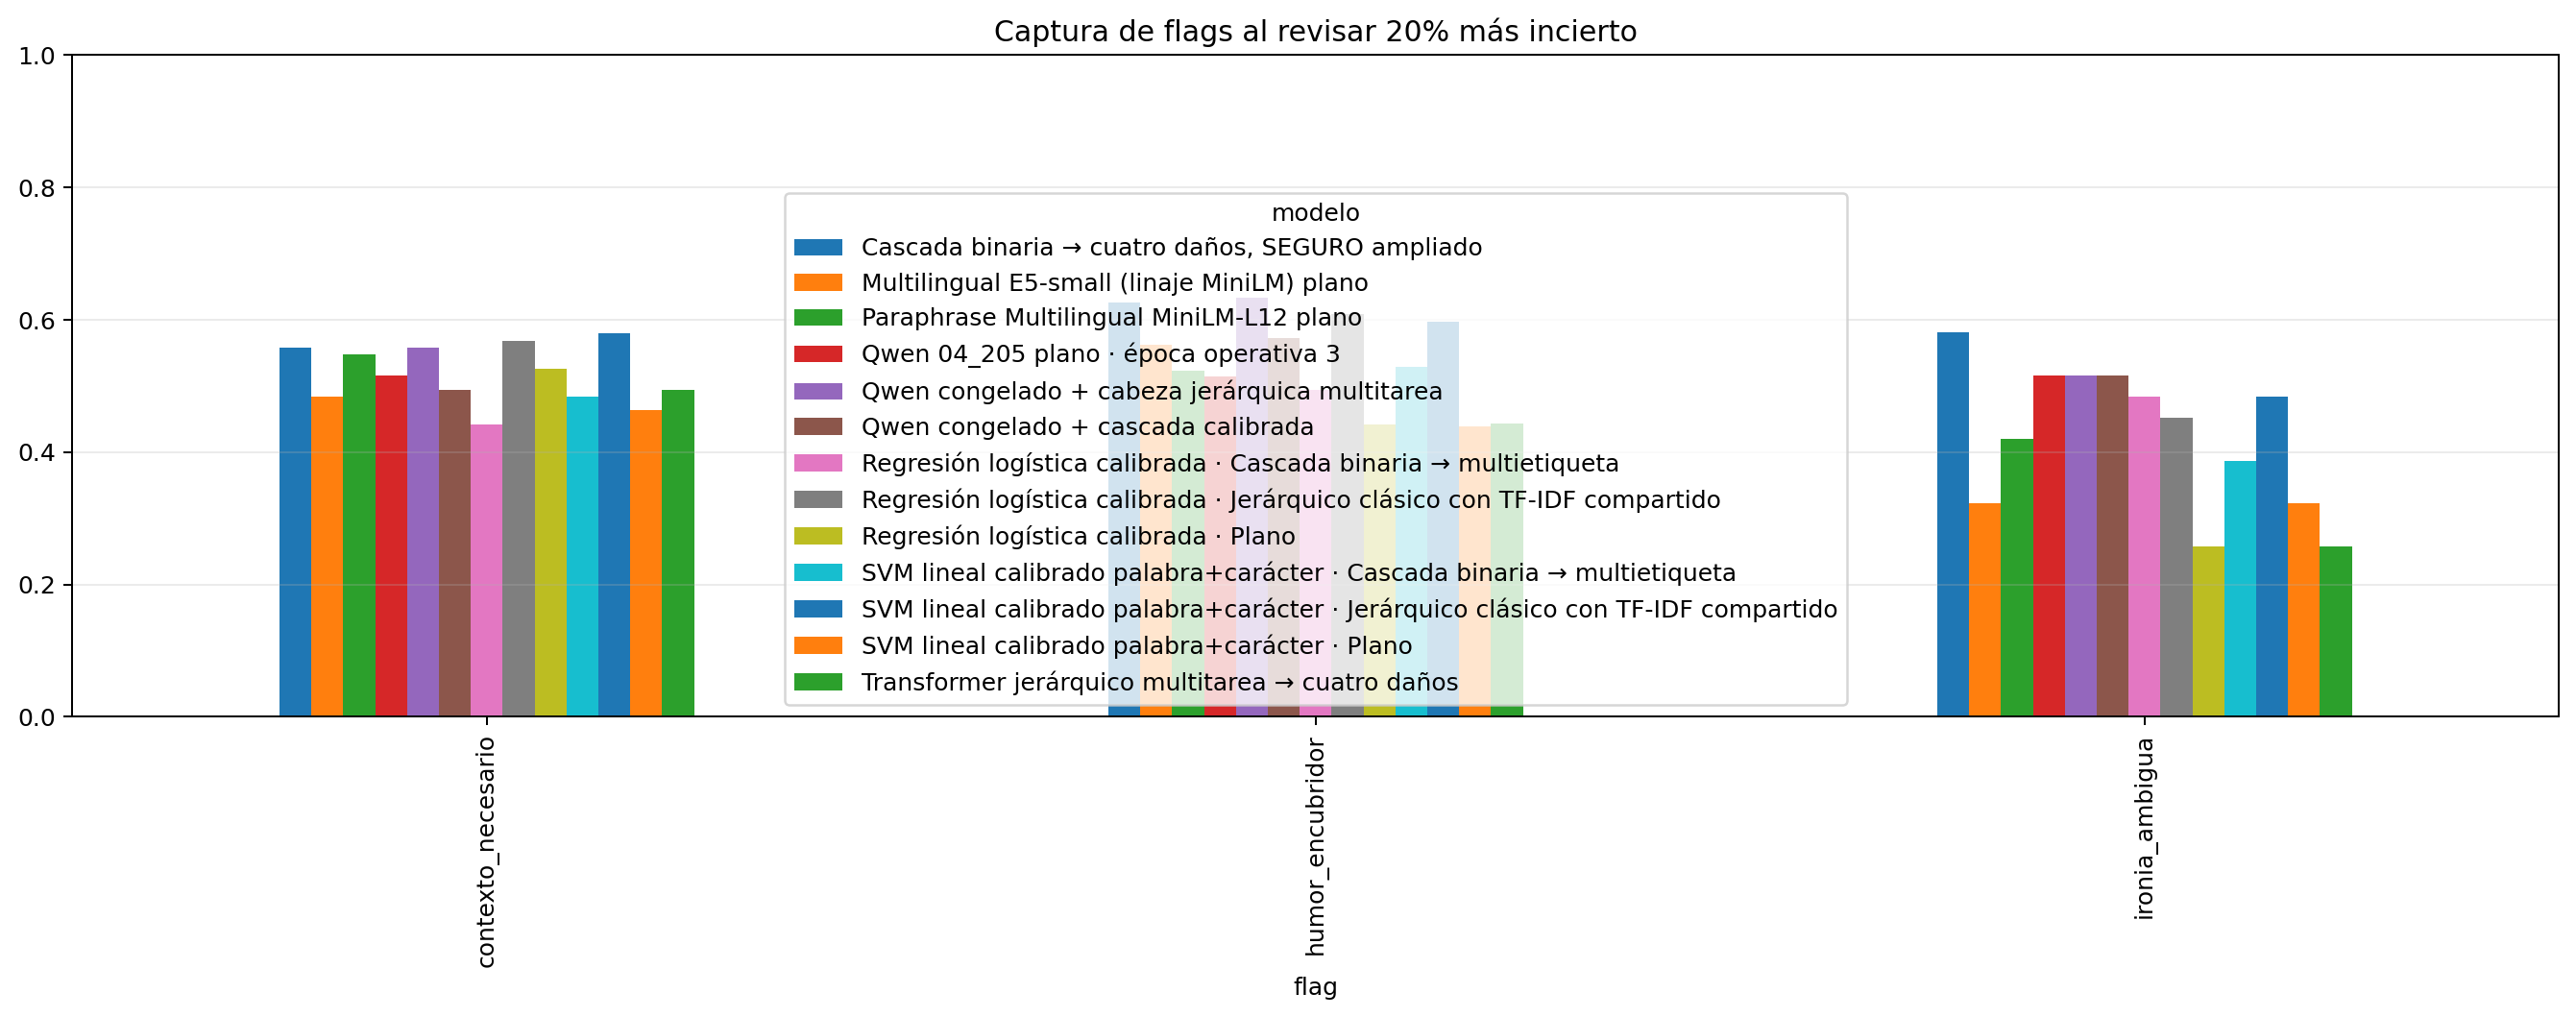

Informe reproducible: `resultados\INFORME_AUDITORIA_FINAS_FLAGS_MODELOS_4.md`

In [5]:
for figure in (audit4.FIGURE_DIR / 'desempeno_fino.png', audit4.FIGURE_DIR / 'captura_flags.png'):
    if figure.exists():
        display(Image(filename=str(figure)))
display(Markdown(f'Informe reproducible: `{audit4.REPORT_PATH.relative_to(ROOT)}`'))

## Interpretación

La comparación principal entre modelos sigue siendo por las cuatro etiquetas gruesas y `SEGURO`. Esta auditoría responde dos preguntas complementarias: (1) si el desempeño se mantiene en cada fenómeno fino y (2) si los flags transversales se concentran entre los casos que el modelo enviaría a revisión. Para afirmar que la supervisión auxiliar mejora causalmente el modelo se requiere comparar una ablación Qwen idéntica con y sin las pérdidas auxiliares.